# Script for the forthcoming article on Probability and Monte Carlo Simulations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Berksons Paradox

Text(0, 0.5, 'Character')

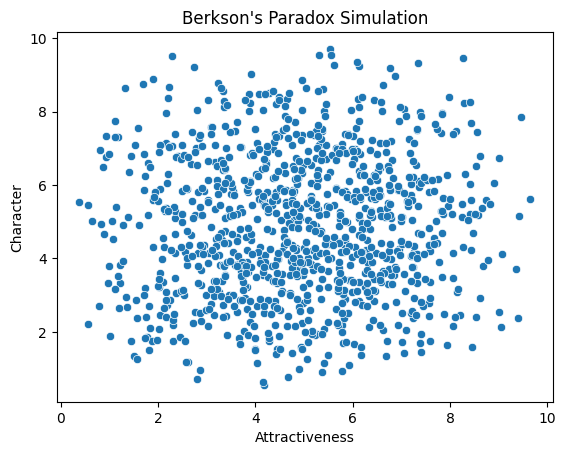

In [3]:
# Set Paramenters

n = 1000
alpha = 3
beta = 3

# Simulate Data
attractiveness = np.random.beta(alpha, beta, n)
attractiveness = attractiveness * 10

character = np.random.beta(alpha, beta, n)
character = character * 10

# Create DataFrame
berksons_df = pd.DataFrame({
    'attractiveness': attractiveness,
    'character': character
})

# Plot the Data
sns.scatterplot(data=berksons_df, x='attractiveness', y='character')
plt.title("Berkson's Paradox Simulation")
plt.xlabel("Attractiveness")
plt.ylabel("Character")


In [4]:
# Regress character on attractiveness to show that there is no correlation
import statsmodels.api as sm

# Add intercept
X_with_const = sm.add_constant(berksons_df[['attractiveness']])

# determine dependent variable (doesnt matter here)
y = berksons_df['character']

# fit OLS
sm_model = sm.OLS(y, X_with_const).fit()

# 3. Print the results (includes Coeff, P-values, and 95% Conf. Intervals)
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.455
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.228
Time:                        18:34:55   Log-Likelihood:                -2064.1
No. Observations:                1000   AIC:                             4132.
Df Residuals:                     998   BIC:                             4142.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.6876      0.168     27.

In [5]:
# Add a selection bias where the sum of attractiveness and character is >14
berksons_df["bias"] = (berksons_df['attractiveness'] + berksons_df['character']) > 14

In [6]:
selected_group = berksons_df[berksons_df["bias"] == True]

X = sm.add_constant(selected_group['attractiveness'])
y = selected_group['character']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     67.38
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.21e-11
Time:                        18:34:55   Log-Likelihood:                -64.793
No. Observations:                  55   AIC:                             133.6
Df Residuals:                      53   BIC:                             137.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             13.8103      0.754     18.

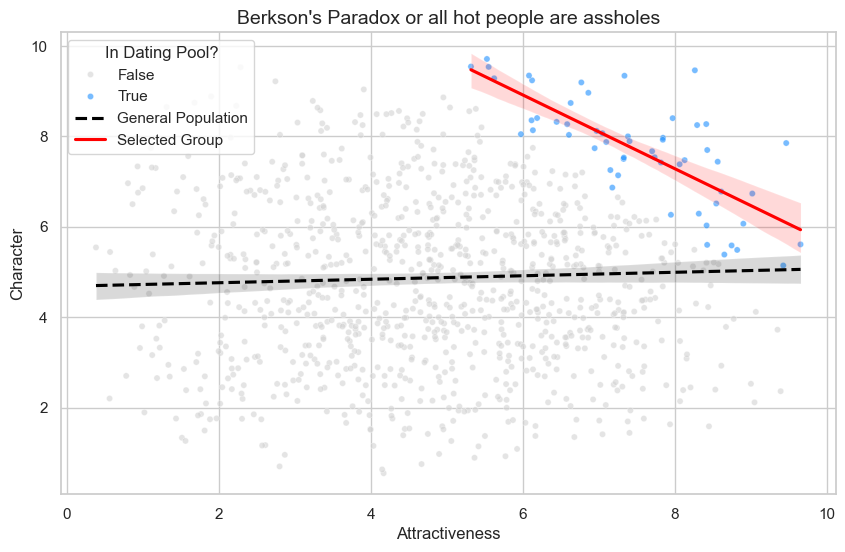

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot  points colored by the bias column
sns.scatterplot(data=berksons_df, x='attractiveness', y='character', 
                hue='bias', palette={True: 'dodgerblue', False: 'lightgray'}, 
                alpha=0.6, s=20)

# Regression Line for full pop
sns.regplot(data=berksons_df, x='attractiveness', y='character', 
            scatter=False, color='black', label='General Population',
            line_kws={"linestyle": "--"})

#Regression Line for selected group
sns.regplot(data=berksons_df[berksons_df['bias'] == True], 
            x='attractiveness', y='character', 
            scatter=False, color='red', label='Selected Group')

#Formatting
plt.title("Berkson's Paradox or all hot people are assholes", fontsize=14)
plt.xlabel("Attractiveness")
plt.ylabel("Character")
plt.legend(title="In Dating Pool?")
plt.show()

# Winning by loosing

Plots and CSV generated.


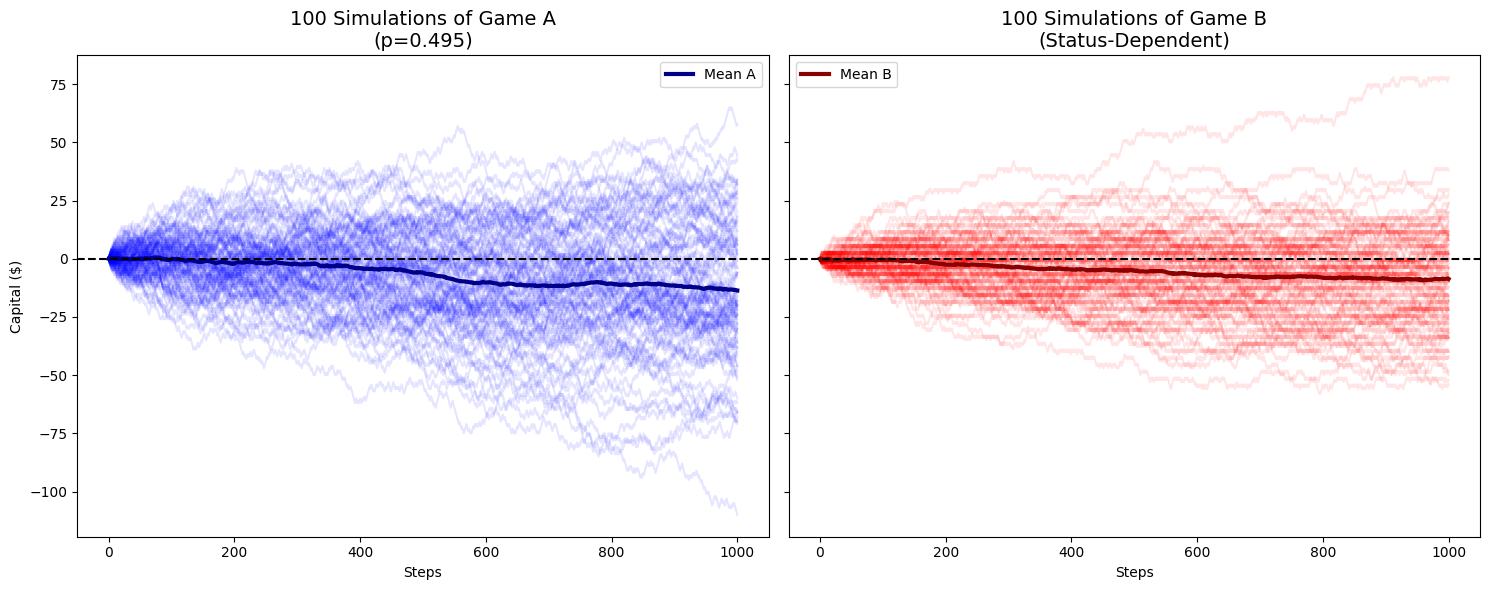

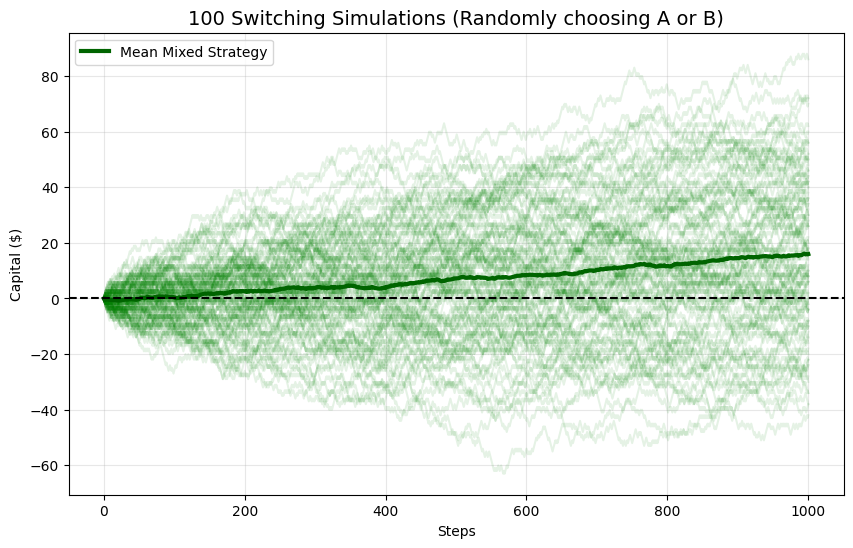

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def play_game_a(current_money):
    return current_money + 1 if np.random.random() < 0.495 else current_money - 1

def play_game_b(current_money):
    p = 0.095 if current_money % 3 == 0 else 0.745
    return current_money + 1 if np.random.random() < p else current_money - 1

def run_simulation(strategy, n_sims=100, n_steps=1000):
    all_paths = np.zeros((n_sims, n_steps + 1))
    for i in range(n_sims):
        money = 0
        for t in range(1, n_steps + 1):
            if strategy == 'A':
                money = play_game_a(money)
            elif strategy == 'B':
                money = play_game_b(money)
            elif strategy == 'Mixed':
                if np.random.random() < 0.5:
                    money = play_game_a(money)
                else:
                    money = play_game_b(money)
            all_paths[i, t] = money
    return all_paths

n_sims = 100
n_steps = 1000

paths_a = run_simulation('A', n_sims, n_steps)
paths_b = run_simulation('B', n_sims, n_steps)
paths_mixed = run_simulation('Mixed', n_sims, n_steps)

# Plot 1: Game A and Game B next to each other
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i in range(n_sims):
    ax1.plot(paths_a[i], color='blue', alpha=0.1)
    ax2.plot(paths_b[i], color='red', alpha=0.1)

ax1.plot(np.mean(paths_a, axis=0), color='darkblue', linewidth=3, label='Mean A')
ax2.plot(np.mean(paths_b, axis=0), color='darkred', linewidth=3, label='Mean B')

ax1.set_title("100 Simulations of Game A\n(p=0.495)", fontsize=14)
ax1.set_xlabel("Steps")
ax1.set_ylabel("Capital ($)")
ax1.axhline(0, color='black', linestyle='--')
ax1.legend()

ax2.set_title("100 Simulations of Game B\n(Status-Dependent)", fontsize=14)
ax2.set_xlabel("Steps")
ax2.axhline(0, color='black', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.savefig('parrondo_a_b.png')

# Plot 2: Switching simulations
plt.figure(figsize=(10, 6))
for i in range(n_sims):
    plt.plot(paths_mixed[i], color='green', alpha=0.1)
plt.plot(np.mean(paths_mixed, axis=0), color='darkgreen', linewidth=3, label='Mean Mixed Strategy')
plt.axhline(0, color='black', linestyle='--')
plt.title("100 Switching Simulations (Randomly choosing A or B)", fontsize=14)
plt.xlabel("Steps")
plt.ylabel("Capital ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('parrondo_mixed.png')

# Save data to CSV (means)
df_means = pd.DataFrame({
    'Step': np.arange(n_steps + 1),
    'Mean_A': np.mean(paths_a, axis=0),
    'Mean_B': np.mean(paths_b, axis=0),
    'Mean_Mixed': np.mean(paths_mixed, axis=0)
})
df_means.to_csv('parrondo_results.csv', index=False)

print("Plots and CSV generated.")

# Optimal choice

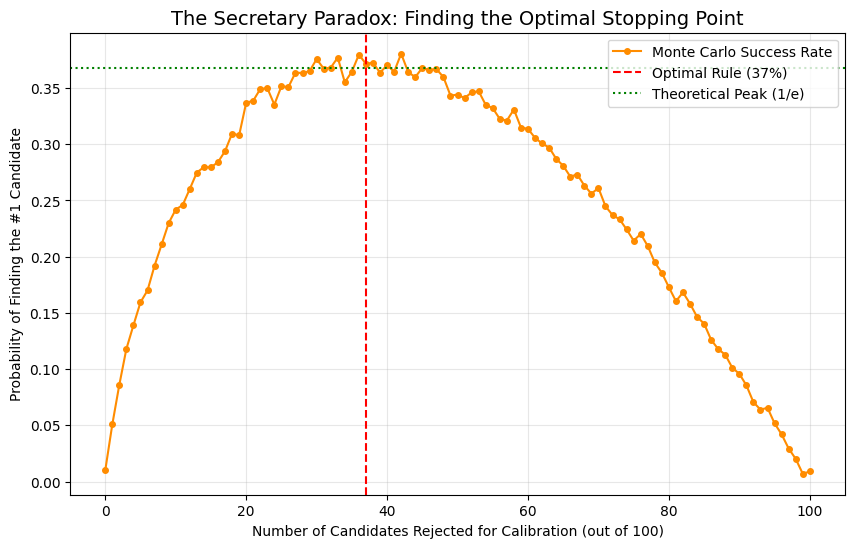

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def secretary_success_rate(n_candidates=100, stop_at=37, trials=5000):
    successes = 0
    for _ in range(trials):
        candidates = np.random.random(n_candidates)
        best_overall = np.max(candidates)
        
        # Calibration phase
        if stop_at == 0:
            best_seen = -1.0
        else:
            best_seen = np.max(candidates[:stop_at])
        
        # Selection phase
        chosen = candidates[-1] # Default to last
        for i in range(stop_at, n_candidates):
            if candidates[i] > best_seen:
                chosen = candidates[i]
                break
        
        if chosen == best_overall:
            successes += 1
            
    return successes / trials

# Test different stopping points
n_c = 100
stop_points = np.arange(0, 101)
success_rates = [secretary_success_rate(n_c, s) for s in stop_points]

plt.figure(figsize=(10, 6))
plt.plot(stop_points, success_rates, marker='o', markersize=4, color='darkorange', label='Monte Carlo Success Rate')
plt.axvline(37, color='red', linestyle='--', label='Optimal Rule (37%)')
plt.axhline(1/np.e, color='green', linestyle=':', label='Theoretical Peak (1/e)')

plt.title("The Secretary Paradox: Finding the Optimal Stopping Point", fontsize=14)
plt.xlabel("Number of Candidates Rejected for Calibration (out of 100)")
plt.ylabel("Probability of Finding the #1 Candidate")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('secretary_optimization.png')

# Save data for csv
df_secretary = pd.DataFrame({'StopPoint': stop_points, 'SuccessRate': success_rates})
df_secretary.to_csv('secretary_results.csv', index=False)